In [1]:
""""
This notebook looks uses unsupervised learning methods K-means clustering 
and Gaussian Mixture Model to identify weight clusters associated with empty,
partially empty, and full vehicles. 
"""

'"\nThis notebook looks uses unsupervised learning methods K-means clustering \nand Gaussian Mixture Model to identify weight clusters associated with empty,\npartially empty, and full vehicles. \n'

In [154]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Capstone_Data") \
    .master("local[*]") \
    .getOrCreate()


In [155]:
#historical dataset 2019 - 2023
df = spark.read.csv("Data\Raw_Data\Weigh_in_Motion_19_23.csv", header=True, inferSchema=True)
df.show(5)

<>:2: SyntaxWarning: invalid escape sequence '\R'
<>:2: SyntaxWarning: invalid escape sequence '\R'
C:\Users\rubie\AppData\Local\Temp\ipykernel_13752\4199683296.py:2: SyntaxWarning: invalid escape sequence '\R'
  df = spark.read.csv("Data\Raw_Data\Weigh_in_Motion_19_23.csv", header=True, inferSchema=True)


+---------+----+-----+---+----+------+------+----+-----+-----+---------+----+---------+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+---------+---------+
|direction|year|month|day|hour|minute|second|lane|class|speed|num_axles| gvw|wheelbase| wt1|spc1| wt2|spc2| wt3|spc3| wt4|spc4| wt5|spc5| wt6|spc6| wt7|spc7| wt8|spc8| wt9|spc9|wt10|spc10|wt11|spc11|wt12|spc12|wt13|spc13|wt14|spc14|wt15|spc15|wt16|spc16|wt17|dirtravel|yearmonth|
+---------+----+-----+---+----+------+------+----+-----+-----+---------+----+---------+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+---------+---------+
|       QB|  23|    5|  8|  17|    53|    16|   2|    2|   49|        2|4880|      9.5|2700| 9.5|2180|NULL|NULL|NULL|NULL|NULL|NULL|NULL|NULL|NULL|NULL|NULL|NUL

In [156]:
df2 = spark.read.csv("Data\Raw_Data\Weigh_in_Motion_24_25.csv", header=True, inferSchema=True)
df2.show(5)

<>:1: SyntaxWarning: invalid escape sequence '\R'
<>:1: SyntaxWarning: invalid escape sequence '\R'
C:\Users\rubie\AppData\Local\Temp\ipykernel_13752\4258952591.py:1: SyntaxWarning: invalid escape sequence '\R'
  df2 = spark.read.csv("Data\Raw_Data\Weigh_in_Motion_24_25.csv", header=True, inferSchema=True)


+---------+----+-----+---+----+------+------+----+-----+-----+---------+-----+---------+----+----+-----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+---------+---------+
|direction|year|month|day|hour|minute|second|lane|class|speed|num_axles|  gvw|wheelbase| wt1|spc1|  wt2|spc2| wt3|spc3| wt4|spc4| wt5|spc5| wt6|spc6| wt7|spc7| wt8|spc8| wt9|spc9|wt10|spc10|wt11|spc11|wt12|spc12|wt13|spc13|wt14|spc14|wt15|spc15|wt16|spc16|wt17|dirtravel|yearmonth|
+---------+----+-----+---+----+------+------+----+-----+-----+---------+-----+---------+----+----+-----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+---------+---------+
|       QB|  24|    8| 26|   6|    30|    55|   2|    2|   52|        2| 4400|      9.4|2600| 9.4| 1800|NULL|NULL|NULL|NULL|NULL|NULL|NULL|NULL|NULL|NULL|

In [157]:
#aggregating both datasets into 1
df3 = df.union(df2)

In [158]:
#Creating a date column
from pyspark.sql.functions import col, concat, lpad
df4 = df3.withColumn(
    "date",
    concat(
        col("year"),
        lpad(col("month"), 2, "0"),  
        lpad(col("day"), 2, "0")
    )
)

df4.show(5)



+---------+----+-----+---+----+------+------+----+-----+-----+---------+----+---------+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+---------+---------+------+
|direction|year|month|day|hour|minute|second|lane|class|speed|num_axles| gvw|wheelbase| wt1|spc1| wt2|spc2| wt3|spc3| wt4|spc4| wt5|spc5| wt6|spc6| wt7|spc7| wt8|spc8| wt9|spc9|wt10|spc10|wt11|spc11|wt12|spc12|wt13|spc13|wt14|spc14|wt15|spc15|wt16|spc16|wt17|dirtravel|yearmonth|  date|
+---------+----+-----+---+----+------+------+----+-----+-----+---------+----+---------+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+---------+---------+------+
|       QB|  23|    5|  8|  17|    53|    16|   2|    2|   49|        2|4880|      9.5|2700| 9.5|2180|NULL|NULL|NULL|NULL|NULL|NULL|NULL|NU

In [159]:
#Filtering for QueensBound Data and casting gvw column as float type
from pyspark.sql import functions as F

df5 = df4.filter("direction = 'QB'").withColumn("gvw", F.col("gvw").cast("float"))

In [160]:
# Removing outliers *asssume pandas df
def remove_outliers_iqr(df):
    Q1 = df["gvw"].quantile(0.25)
    Q3 = df["gvw"].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_iqr = df[(df["gvw"] < lower_bound) | (df["gvw"] > upper_bound)]
    
    print(f"Outlier Count: {len(outliers_iqr)}")
    print(f"Original Count: {len(df)}")
    print(f"Remaining count: {len(df) - len(outliers_iqr)}")
    print(f"Outlier percentage: {len(outliers_iqr)/len(df)*100:.2f}%")
    print(f"Upper bound: {upper_bound:.2f}, Lower bound: {lower_bound:.2f}")
    
    # Return filtered dataframe
    return df[(df["gvw"] >= lower_bound) & (df["gvw"] <= upper_bound)]

In [161]:
#eliminate outliers from spark df
from pyspark.sql import functions as F

def remove_outliers_iqr2(df_spark, col_name):
    # Step 1: Get Q1 and Q3
    q1, q3 = df_spark.approxQuantile(col_name, [0.25, 0.75], 0.01)

    # Step 2: Compute IQR
    iqr = q3 - q1

    # Step 3: Define bounds
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    print(f"Upper bound: {upper_bound}, Lower bound: {lower_bound}")

    # Step 4: Filter outliers
    return df_spark.filter((F.col(col_name) >= lower_bound) & (F.col(col_name) <= upper_bound))

Class 1

In [162]:
import pandas as pd
#filtering by class
class_num = 1

count = df5.filter(f"class = {class_num}").count()
print(f"Number of records {count}")

class_df = df5.filter(f"class = {class_num}").toPandas()

Number of records 137075


In [163]:
#converting date col to pandas date object
class_df["date"] = pd.to_datetime(class_df["date"], format="%y%m%d")

c:\Users\rubie\anaconda3\envs\Fall25_Capstone\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


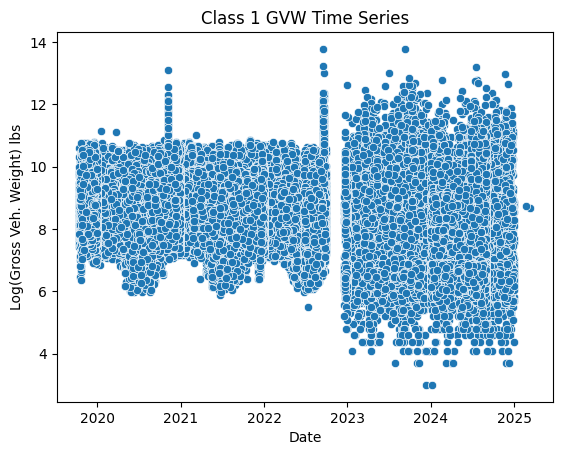

In [164]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

class_df["log_gvw"] = np.log(class_df["gvw"])
sns.scatterplot(data=class_df, x = "date", y="log_gvw")
plt.title(f"Class {class_num} GVW Time Series")
plt.xlabel("Date")
plt.ylabel("Log(Gross Veh. Weight) lbs")
plt.show()

In [165]:
class_df["gvw"].describe()

count    137075.000000
mean       5510.365723
std       11173.467773
min           0.000000
25%         780.000000
50%        3000.000000
75%        6890.000000
max      959920.000000
Name: gvw, dtype: float64

In [166]:
class_df2 = remove_outliers_iqr(class_df)
class_df2["gvw"].describe()

Outlier Count: 6817
Original Count: 137075
Remaining count: 130258
Outlier percentage: 4.97%
Upper bound: 16055.00, Lower bound: -8385.00


count    130258.000000
mean       3898.815430
std        3537.319336
min           0.000000
25%         740.000000
50%        2760.000000
75%        6190.000000
max       16040.000000
Name: gvw, dtype: float64

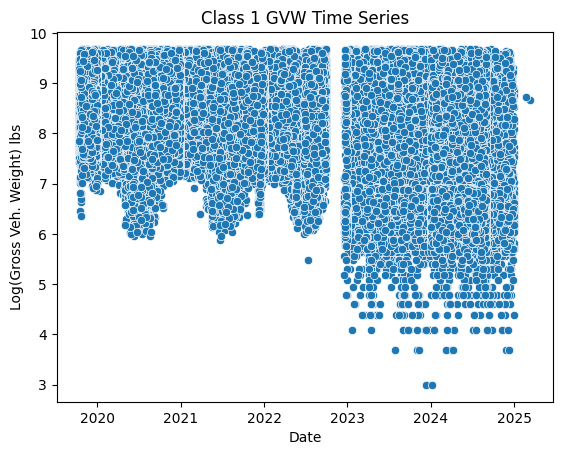

In [167]:
sns.scatterplot(data=class_df2, x = "date", y="log_gvw")
plt.title(f"Class {class_num} GVW Time Series")
plt.xlabel("Date")
plt.ylabel("Log(Gross Veh. Weight) lbs")
plt.show()

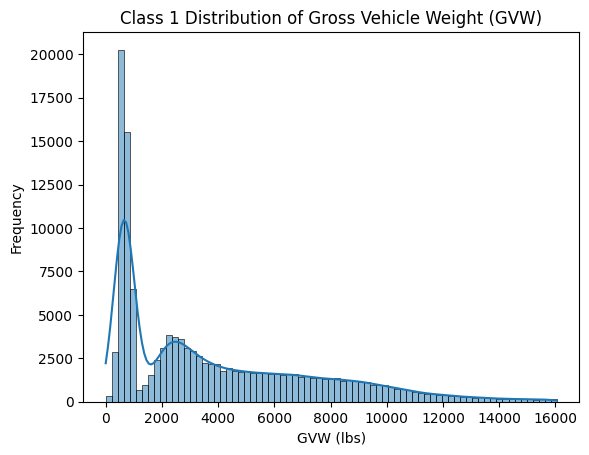

In [168]:
import seaborn as sns
import matplotlib.pyplot as plt

#GVW visualization
sns.histplot(data=class_df2, x="gvw", kde=True)
plt.title(f"Class {class_num} Distribution of Gross Vehicle Weight (GVW)")
plt.xlabel("GVW (lbs)")
plt.ylabel("Frequency")
plt.show()

Class 2

In [169]:
import pandas as pd
#filtering by class
class_num = 2
sample_ratio = 0.01

count = df5.filter(f"class = {class_num}").count()
print(f"Number of records {count}")
print(f"Number of records sampled {count*sample_ratio}")

Number of records 63669765
Number of records sampled 636697.65


In [170]:
class_df_spark = df5.filter(f"class = {class_num}")

In [171]:
#Getting statistics of complete dataset
class_df_spark.select("gvw").summary().show()

+-------+------------------+
|summary|               gvw|
+-------+------------------+
|  count|          63669765|
|   mean|3597.0307459121295|
| stddev| 2150.265565594835|
|    min|               0.0|
|    25%|            2670.0|
|    50%|            3370.0|
|    75%|            4200.0|
|    max|          649090.0|
+-------+------------------+



In [172]:

df_no_outliers = remove_outliers_iqr2(class_df_spark, "gvw")
df_no_outliers.show(5)


Upper bound: 6510.0, Lower bound: 350.0
+---------+----+-----+---+----+------+------+----+-----+-----+---------+------+---------+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+---------+---------+------+
|direction|year|month|day|hour|minute|second|lane|class|speed|num_axles|   gvw|wheelbase| wt1|spc1| wt2|spc2| wt3|spc3| wt4|spc4| wt5|spc5| wt6|spc6| wt7|spc7| wt8|spc8| wt9|spc9|wt10|spc10|wt11|spc11|wt12|spc12|wt13|spc13|wt14|spc14|wt15|spc15|wt16|spc16|wt17|dirtravel|yearmonth|  date|
+---------+----+-----+---+----+------+------+----+-----+-----+---------+------+---------+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+---------+---------+------+
|       QB|  23|    5|  8|  17|    53|    16|   2|    2|   49|        2|4880.0|      9.5|2700

In [173]:
#outliers eliminated
a = class_df_spark.count()
b = df_no_outliers.count()
outlier_count = a - b

print(f"Outlier Count: {outlier_count}, Original Count: {a}, Remaining count {b}, Outlier percentage: {outlier_count/a*100:.2f}%")

Outlier Count: 1088872, Original Count: 63669765, Remaining count 62580893, Outlier percentage: 1.71%


In [174]:
#Getting statistics of complete dataset with no outliers
df_no_outliers.select("gvw").summary().show()

+-------+------------------+
|summary|               gvw|
+-------+------------------+
|  count|          62580893|
|   mean|3449.5908973366677|
| stddev|1080.1699316201643|
|    min|             350.0|
|    25%|            2660.0|
|    50%|            3340.0|
|    75%|            4150.0|
|    max|            6510.0|
+-------+------------------+



In [23]:
#Bootstrap to check sampling error
#Outliers removed
sample_vars = []
sample_means = []

for i in range(50):
    class_df = df_no_outliers.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
    ).toPandas()
    
    sample_means.append(class_df["gvw"].mean())
    sample_vars.append(class_df["gvw"].var())
    print(f"{i+1}/50")

1/50
2/50
3/50
4/50
5/50
6/50
7/50
8/50
9/50
10/50
11/50
12/50
13/50
14/50
15/50
16/50
17/50
18/50
19/50
20/50
21/50
22/50
23/50
24/50
25/50
26/50
27/50
28/50
29/50
30/50
31/50
32/50
33/50
34/50
35/50
36/50
37/50
38/50
39/50
40/50
41/50
42/50
43/50
44/50
45/50
46/50
47/50
48/50
49/50
50/50


In [26]:
import statistics as stats
#Mean and error of sample mean

print(stats.mean(sample_means))
print(stats.variance(sample_means))

print(stats.stdev(sample_means)/stats.mean(sample_means)) #Coefficient of variation , CV

3449.7122
1.5811964
0.0003645105


In [ ]:
import statistics as stats
#Mean and error of sample variance

print(stats.mean(sample_vars))
print(stats.variance(sample_vars))

print(stats.stdev(sample_vars)/stats.mean(sample_vars)) #Coefficient of variation , CV

1166866.57
2569211.4159183674
0.0013736583289900791


In [175]:
#Sampled dataset without replacement for visualization
class_df = df_no_outliers.sample(
    withReplacement=False,  
    fraction=sample_ratio,           
    seed=42                 
).toPandas()

In [176]:
#converting date col to pandas date object
class_df["date"] = pd.to_datetime(class_df["date"], format="%y%m%d")

c:\Users\rubie\anaconda3\envs\Fall25_Capstone\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


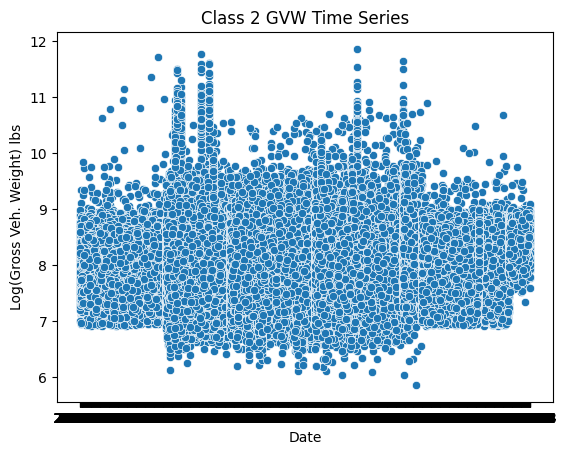

In [177]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#Pre-removing outlier sample time series
og_sample = class_df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,           
    seed=42                 
).toPandas()

og_sample["log_gvw"] = np.log(og_sample["gvw"])
sns.scatterplot(data=og_sample, x="date", y="log_gvw")
plt.title(f"Class {class_num} GVW Time Series")
plt.xlabel("Date")
plt.ylabel("Log(Gross Veh. Weight) lbs")
plt.show()

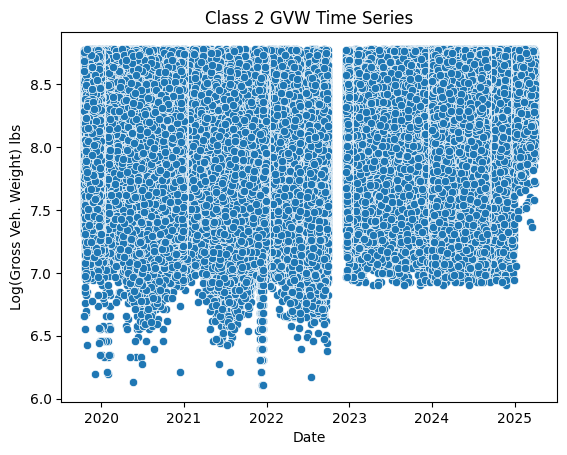

In [178]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#time series post-outlier removal
class_df["log_gvw"] = np.log(class_df["gvw"])
sns.scatterplot(data=class_df, x="date", y="log_gvw")
plt.title(f"Class {class_num} GVW Time Series")
plt.xlabel("Date")
plt.ylabel("Log(Gross Veh. Weight) lbs")
plt.show()

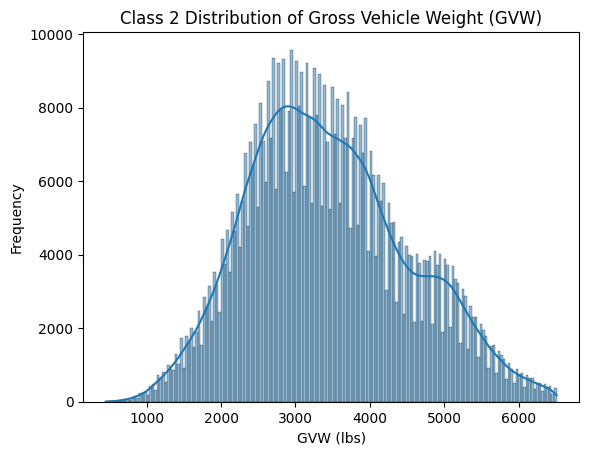

In [179]:
import seaborn as sns
import matplotlib.pyplot as plt

#GVW visualization
sns.histplot(data=class_df, x="gvw", kde=True)
plt.title(f"Class {class_num} Distribution of Gross Vehicle Weight (GVW)")
plt.xlabel("GVW (lbs)")
plt.ylabel("Frequency")
plt.show()

Class 3

In [180]:
import pandas as pd
#filtering by class
class_num = 3
sample_ratio = 0.01

count = df5.filter(f"class = {class_num}").count()
print(f"Number of records {count}")
print(f"Number of records sampled {count*sample_ratio}")

Number of records 10179628
Number of records sampled 101796.28


In [181]:
class_df_spark = df5.filter(f"class = {class_num}")

In [182]:
#Getting statistics of complete dataset
class_df_spark.select("gvw").summary().show()

+-------+------------------+
|summary|               gvw|
+-------+------------------+
|  count|          10179628|
|   mean| 5756.612698420807|
| stddev|3509.7981860333875|
|    min|             500.0|
|    25%|            4190.0|
|    50%|            5400.0|
|    75%|            6660.0|
|    max|          404560.0|
+-------+------------------+



In [183]:

df_no_outliers = remove_outliers_iqr2(class_df_spark, "gvw")
df_no_outliers.show(5)


Upper bound: 10330.0, Lower bound: 490.0
+---------+----+-----+---+----+------+------+----+-----+-----+---------+------+---------+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+---------+---------+------+
|direction|year|month|day|hour|minute|second|lane|class|speed|num_axles|   gvw|wheelbase| wt1|spc1| wt2|spc2| wt3|spc3| wt4|spc4| wt5|spc5| wt6|spc6| wt7|spc7| wt8|spc8| wt9|spc9|wt10|spc10|wt11|spc11|wt12|spc12|wt13|spc13|wt14|spc14|wt15|spc15|wt16|spc16|wt17|dirtravel|yearmonth|  date|
+---------+----+-----+---+----+------+------+----+-----+-----+---------+------+---------+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+---------+---------+------+
|       QB|  23|    8| 31|  17|    38|    47|   1|    3|   11|        2|5820.0|     12.6|346

In [184]:
#outliers eliminated
a = class_df_spark.count()
b = df_no_outliers.count()
outlier_count = a - b

print(f"Outlier Count: {outlier_count}, Original Count: {a}, Remaining count {b}, Outlier percentage: {outlier_count/a*100:.2f}%")

Outlier Count: 438963, Original Count: 10179628, Remaining count 9740665, Outlier percentage: 4.31%


In [185]:
#Getting statistics of complete dataset with no outliers
df_no_outliers.select("gvw").summary().show()

+-------+------------------+
|summary|               gvw|
+-------+------------------+
|  count|           9740665|
|   mean|5348.8043331743775|
| stddev|1689.8283253488003|
|    min|             500.0|
|    25%|            4130.0|
|    50%|            5300.0|
|    75%|            6480.0|
|    max|           10330.0|
+-------+------------------+



In [37]:
#Bootstrap to check sampling error
#Outliers removed
sample_vars = []
sample_means = []

for i in range(50):
    class_df = df_no_outliers.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
    ).toPandas()
    
    sample_means.append(class_df["gvw"].mean())
    sample_vars.append(class_df["gvw"].var())
    print(f"{i+1}/50")

1/50
2/50
3/50
4/50
5/50
6/50
7/50
8/50
9/50
10/50
11/50
12/50
13/50
14/50
15/50
16/50
17/50
18/50
19/50
20/50
21/50
22/50
23/50
24/50
25/50
26/50
27/50
28/50
29/50
30/50
31/50
32/50
33/50
34/50
35/50
36/50
37/50
38/50
39/50
40/50
41/50
42/50
43/50
44/50
45/50
46/50
47/50
48/50
49/50
50/50


In [38]:
import statistics as stats
#Mean and error of sample mean

print(stats.mean(sample_means))
print(stats.variance(sample_means))

print(stats.stdev(sample_means)/stats.mean(sample_means)) #Coefficient of variation , CV

5347.941
25.67205
0.0009474225


In [39]:
import statistics as stats
#Mean and error of sample variance

print(stats.mean(sample_vars))
print(stats.variance(sample_vars))

print(stats.stdev(sample_vars)/stats.mean(sample_vars)) #Coefficient of variation , CV

2856806.46
204106535.31214285
0.005000893848509135


In [186]:
#Sampled dataset without replacement for visualization
class_df = df_no_outliers.sample(
    withReplacement=False,  
    fraction=sample_ratio,           
    seed=42                 
).toPandas()

In [187]:
#converting date col to pandas date object
class_df["date"] = pd.to_datetime(class_df["date"], format="%y%m%d")

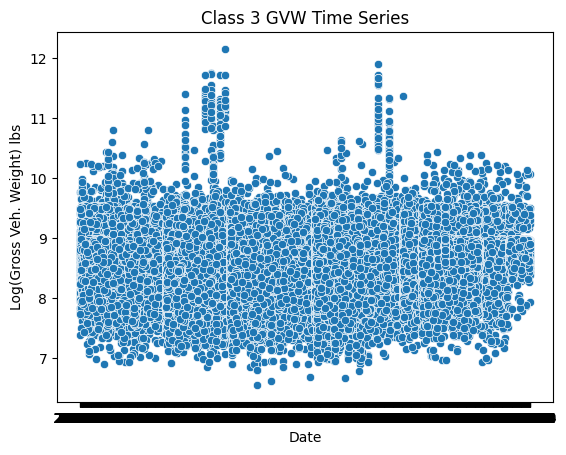

In [188]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#Pre-removing outlier sample time series
og_sample = class_df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,           
    seed=42                 
).toPandas()

og_sample["log_gvw"] = np.log(og_sample["gvw"])
sns.scatterplot(data=og_sample, x="date", y="log_gvw")
plt.title(f"Class {class_num} GVW Time Series")
plt.xlabel("Date")
plt.ylabel("Log(Gross Veh. Weight) lbs")
plt.show()

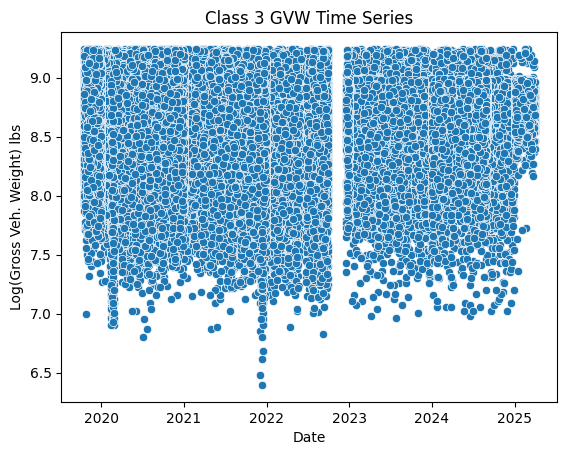

In [189]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#sample time series post outlier removal
class_df["log_gvw"] = np.log(class_df["gvw"])
sns.scatterplot(data=class_df, x="date", y="log_gvw")
plt.title(f"Class {class_num} GVW Time Series")
plt.xlabel("Date")
plt.ylabel("Log(Gross Veh. Weight) lbs")
plt.show()

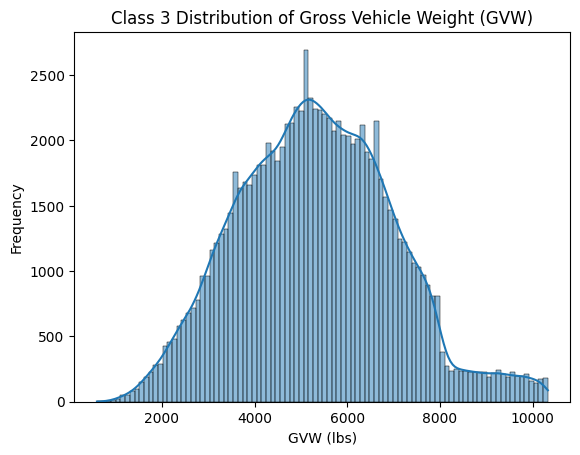

In [190]:
import seaborn as sns
import matplotlib.pyplot as plt

#GVW visualization
sns.histplot(data=class_df, x="gvw", kde=True)
plt.title(f"Class {class_num} Distribution of Gross Vehicle Weight (GVW)")
plt.xlabel("GVW (lbs)")
plt.ylabel("Frequency")
plt.show()

Class 4

In [191]:
import pandas as pd
#filtering by class
class_num = 4

count = df5.filter(f"class = {class_num}").count()
print(count)

class_df = df5.filter(f"class = {class_num}").toPandas()

427491


In [192]:
#converting date col to pandas date object
class_df["date"] = pd.to_datetime(class_df["date"], format="%y%m%d")

c:\Users\rubie\anaconda3\envs\Fall25_Capstone\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


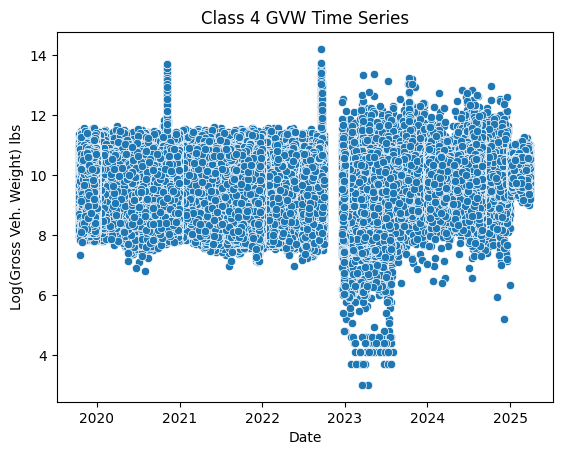

In [193]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

class_df["log_gvw"] = np.log(class_df["gvw"])
sns.scatterplot(data=class_df, x = "date", y="log_gvw")
plt.title(f"Class {class_num} GVW Time Series")
plt.xlabel("Date")
plt.ylabel("Log(Gross Veh. Weight) lbs")
plt.show()

In [194]:
class_df["gvw"].describe()

count    4.274910e+05
mean     2.709891e+04
std      2.054329e+04
min      0.000000e+00
25%      1.698000e+04
50%      2.642000e+04
75%      3.724000e+04
max      1.496860e+06
Name: gvw, dtype: float64

In [195]:
# Removing outliers
class_df["gvw"] = class_df["gvw"].astype("float")
class_df2 = remove_outliers_iqr(class_df)
class_df2["gvw"].describe()

Outlier Count: 2975
Original Count: 427491
Remaining count: 424516
Outlier percentage: 0.70%
Upper bound: 67630.00, Lower bound: -13410.00


count    424516.000000
mean      26280.112976
std       13494.336198
min           0.000000
25%       16900.000000
50%       26280.000000
75%       37060.000000
max       67630.000000
Name: gvw, dtype: float64

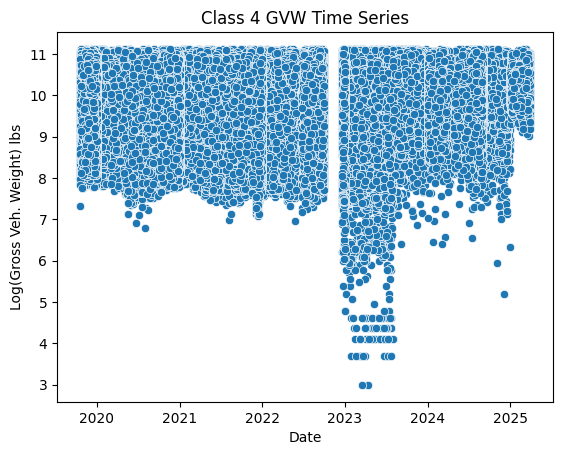

In [196]:
sns.scatterplot(data=class_df2, x = "date", y="log_gvw")
plt.title(f"Class {class_num} GVW Time Series")
plt.xlabel("Date")
plt.ylabel("Log(Gross Veh. Weight) lbs")
plt.show()

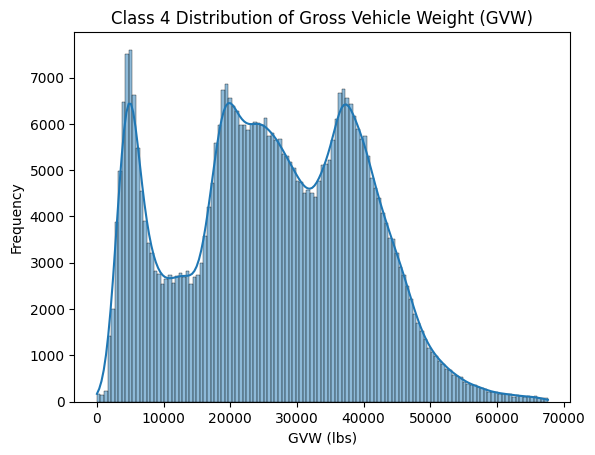

In [197]:
import seaborn as sns
import matplotlib.pyplot as plt

#GVW visualization
sns.histplot(data=class_df2, x="gvw", kde=True)
plt.title(f"Class {class_num} Distribution of Gross Vehicle Weight (GVW)")
plt.xlabel("GVW (lbs)")
plt.ylabel("Frequency")
plt.show()

Class 5

In [198]:
import pandas as pd
#filtering by class
class_num = 5
sample_ratio = 0.01

count = df5.filter(f"class = {class_num}").count()
print(f"Number of records {count}")
print(f"Number of records sampled {count*sample_ratio}")

Number of records 3667223
Number of records sampled 36672.23


In [199]:
class_df_spark = df5.filter(f"class = {class_num}")

In [200]:
#Getting statistics of complete dataset
class_df_spark.select("gvw").summary().show()

+-------+------------------+
|summary|               gvw|
+-------+------------------+
|  count|           3667223|
|   mean|18689.092602222445|
| stddev|12041.373410019722|
|    min|               0.0|
|    25%|           11140.0|
|    50%|           18630.0|
|    75%|           23900.0|
|    max|          886540.0|
+-------+------------------+



In [201]:
df_no_outliers = remove_outliers_iqr2(class_df_spark, "gvw")
df_no_outliers.show(5)

Upper bound: 42785.0, Lower bound: -7895.0
+---------+----+-----+---+----+------+------+----+-----+-----+---------+-------+---------+----+----+-----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+---------+---------+------+
|direction|year|month|day|hour|minute|second|lane|class|speed|num_axles|    gvw|wheelbase| wt1|spc1|  wt2|spc2| wt3|spc3| wt4|spc4| wt5|spc5| wt6|spc6| wt7|spc7| wt8|spc8| wt9|spc9|wt10|spc10|wt11|spc11|wt12|spc12|wt13|spc13|wt14|spc14|wt15|spc15|wt16|spc16|wt17|dirtravel|yearmonth|  date|
+---------+----+-----+---+----+------+------+----+-----+-----+---------+-------+---------+----+----+-----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+---------+---------+------+
|       QB|  23|   11|  1|  15|    54|    46|   1|    5|   49|        2|20080.0|    

In [202]:
#outliers eliminated
a = class_df_spark.count()
b = df_no_outliers.count()
outlier_count = a - b

print(f"Outlier Count: {outlier_count}, Original Count: {a}, Remaining count {b}, Outlier percentage: {outlier_count/a*100:.2f}%")

Outlier Count: 19143, Original Count: 3667223, Remaining count 3648080, Outlier percentage: 0.52%


In [203]:
#Getting statistics of complete dataset with no outliers
df_no_outliers.select("gvw").summary().show()

+-------+------------------+
|summary|               gvw|
+-------+------------------+
|  count|           3648080|
|   mean|18234.827687441066|
| stddev|7419.8639386840405|
|    min|               0.0|
|    25%|           11100.0|
|    50%|           18560.0|
|    75%|           23820.0|
|    max|           42780.0|
+-------+------------------+



In [57]:
#Bootstrap to check sampling error
#Outliers removed
sample_vars = []
sample_means = []

for i in range(50):
    class_df = df_no_outliers.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
    ).toPandas()
    
    sample_means.append(class_df["gvw"].mean())
    sample_vars.append(class_df["gvw"].var())
    print(f"{i+1}/50")

1/50
2/50
3/50
4/50
5/50
6/50
7/50
8/50
9/50
10/50
11/50
12/50
13/50
14/50
15/50
16/50
17/50
18/50
19/50
20/50
21/50
22/50
23/50
24/50
25/50
26/50
27/50
28/50
29/50
30/50
31/50
32/50
33/50
34/50
35/50
36/50
37/50
38/50
39/50
40/50
41/50
42/50
43/50
44/50
45/50
46/50
47/50
48/50
49/50
50/50


In [58]:
import statistics as stats
#Mean and error of sample mean

print(stats.mean(sample_means))
print(stats.variance(sample_means))

print(stats.stdev(sample_means)/stats.mean(sample_means)) #Coefficient of variation , CV

18228.27
1822.4207
0.0023419568


In [59]:
import statistics as stats
#Mean and error of sample variance

print(stats.mean(sample_vars))
print(stats.variance(sample_vars))

print(stats.stdev(sample_vars)/stats.mean(sample_vars)) #Coefficient of variation , CV

54974630.32
99748684053.6098
0.005745016361221691


In [204]:
#Sampled dataset without replacement for visualization
class_df = df_no_outliers.sample(
    withReplacement=False,  
    fraction=sample_ratio,           
    seed=42                 
).toPandas()

In [205]:
#converting date col to pandas date object
class_df["date"] = pd.to_datetime(class_df["date"], format="%y%m%d")

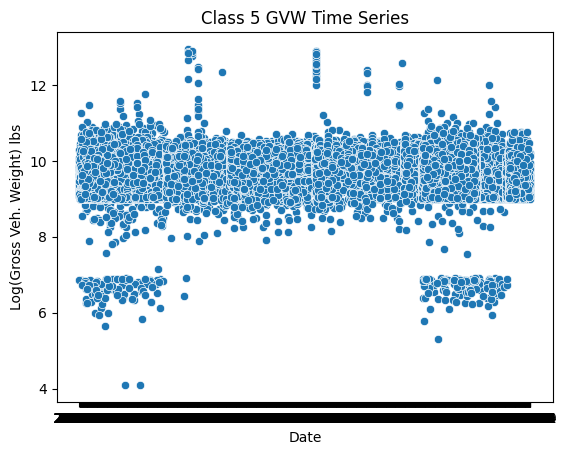

In [206]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#Pre-removing outlier sample time series
og_sample = class_df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,           
    seed=42                 
).toPandas()

og_sample["log_gvw"] = np.log(og_sample["gvw"])
sns.scatterplot(data=og_sample, x="date", y="log_gvw")
plt.title(f"Class {class_num} GVW Time Series")
plt.xlabel("Date")
plt.ylabel("Log(Gross Veh. Weight) lbs")
plt.show()

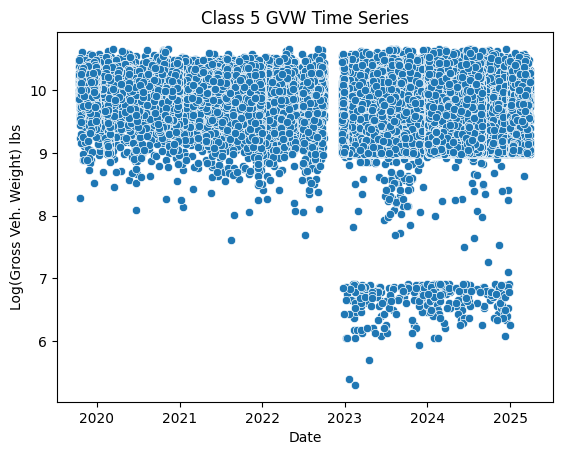

In [207]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#sample time series post outlier removal
class_df["log_gvw"] = np.log(class_df["gvw"])
sns.scatterplot(data=class_df, x="date", y="log_gvw")
plt.title(f"Class {class_num} GVW Time Series")
plt.xlabel("Date")
plt.ylabel("Log(Gross Veh. Weight) lbs")
plt.show()

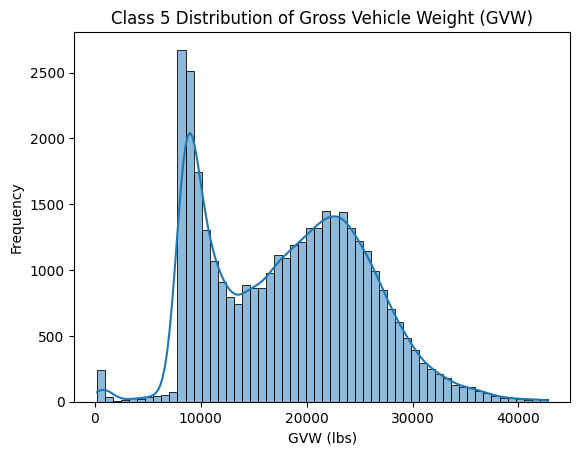

In [208]:
import seaborn as sns
import matplotlib.pyplot as plt

#GVW visualization
sns.histplot(data=class_df, x="gvw", kde=True)
plt.title(f"Class {class_num} Distribution of Gross Vehicle Weight (GVW)")
plt.xlabel("GVW (lbs)")
plt.ylabel("Frequency")
plt.show()

Class 6

In [209]:
import pandas as pd
#filtering by class
class_num = 6
sample_ratio = 0.01

count = df5.filter(f"class = {class_num}").count()
print(f"Number of records {count}")
print(f"Number of records sampled {count*sample_ratio}")

Number of records 1079144
Number of records sampled 10791.44


In [210]:
class_df_spark = df5.filter(f"class = {class_num}")

In [211]:
#Getting statistics of complete dataset
class_df_spark.select("gvw").summary().show()

+-------+-----------------+
|summary|              gvw|
+-------+-----------------+
|  count|          1079144|
|   mean|37380.26302328512|
| stddev|22549.52766738734|
|    min|             60.0|
|    25%|          26940.0|
|    50%|          37160.0|
|    75%|          45550.0|
|    max|        1083890.0|
+-------+-----------------+



In [212]:
df_no_outliers = remove_outliers_iqr2(class_df_spark, "gvw")
df_no_outliers.show(5)

Upper bound: 72865.0, Lower bound: -695.0
+---------+----+-----+---+----+------+------+----+-----+-----+---------+-------+---------+-----+----+-----+----+-----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+---------+---------+------+
|direction|year|month|day|hour|minute|second|lane|class|speed|num_axles|    gvw|wheelbase|  wt1|spc1|  wt2|spc2|  wt3|spc3| wt4|spc4| wt5|spc5| wt6|spc6| wt7|spc7| wt8|spc8| wt9|spc9|wt10|spc10|wt11|spc11|wt12|spc12|wt13|spc13|wt14|spc14|wt15|spc15|wt16|spc16|wt17|dirtravel|yearmonth|  date|
+---------+----+-----+---+----+------+------+----+-----+-----+---------+-------+---------+-----+----+-----+----+-----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+---------+---------+------+
|       QB|  23|    7| 11|  14|    17|    28|   1|    6|   44|        3|31040.0

In [213]:
#outliers eliminated
a = class_df_spark.count()
b = df_no_outliers.count()
outlier_count = a - b

print(f"Outlier Count: {outlier_count}, Original Count: {a}, Remaining count {b}, Outlier percentage: {outlier_count/a*100:.2f}%")

Outlier Count: 8517, Original Count: 1079144, Remaining count 1070627, Outlier percentage: 0.79%


In [214]:
#Getting statistics of complete dataset with no outliers
df_no_outliers.select("gvw").summary().show()

+-------+------------------+
|summary|               gvw|
+-------+------------------+
|  count|           1070627|
|   mean|36389.586494642856|
| stddev|12521.413052478487|
|    min|              60.0|
|    25%|           26860.0|
|    50%|           37040.0|
|    75%|           45340.0|
|    max|           72860.0|
+-------+------------------+



In [70]:
#Bootstrap to check sampling error
#Outliers removed
sample_vars = []
sample_means = []

for i in range(50):
    class_df = df_no_outliers.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
    ).toPandas()
    
    sample_means.append(class_df["gvw"].mean())
    sample_vars.append(class_df["gvw"].var())
    print(f"{i+1}/50")

1/50
2/50
3/50
4/50
5/50
6/50
7/50
8/50
9/50
10/50
11/50
12/50
13/50
14/50
15/50
16/50
17/50
18/50
19/50
20/50
21/50
22/50
23/50
24/50
25/50
26/50
27/50
28/50
29/50
30/50
31/50
32/50
33/50
34/50
35/50
36/50
37/50
38/50
39/50
40/50
41/50
42/50
43/50
44/50
45/50
46/50
47/50
48/50
49/50
50/50


In [71]:
import statistics as stats
#Mean and error of sample mean

print(stats.mean(sample_means))
print(stats.variance(sample_means))

print(stats.stdev(sample_means)/stats.mean(sample_means)) #Coefficient of variation , CV

36389.71
17849.969
0.0036714713


In [72]:
import statistics as stats
#Mean and error of sample variance

print(stats.mean(sample_vars))
print(stats.variance(sample_vars))

print(stats.stdev(sample_vars)/stats.mean(sample_vars)) #Coefficient of variation , CV

156997727.04
2585736692761.182
0.01024233046954851


In [215]:
#Sampled dataset without replacement for visualization
class_df = df_no_outliers.sample(
    withReplacement=False,  
    fraction=sample_ratio,           
    seed=42                 
).toPandas()

In [216]:
#converting date col to pandas date object
class_df["date"] = pd.to_datetime(class_df["date"], format="%y%m%d")

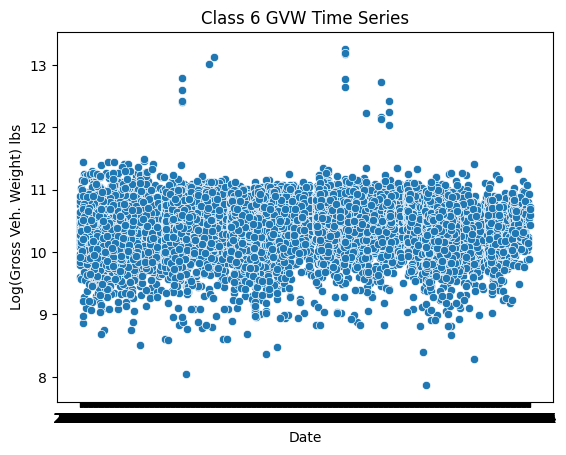

In [217]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#Pre-removing outlier sample time series
og_sample = class_df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,           
    seed=42                 
).toPandas()

og_sample["log_gvw"] = np.log(og_sample["gvw"])
sns.scatterplot(data=og_sample, x="date", y="log_gvw")
plt.title(f"Class {class_num} GVW Time Series")
plt.xlabel("Date")
plt.ylabel("Log(Gross Veh. Weight) lbs")
plt.show()

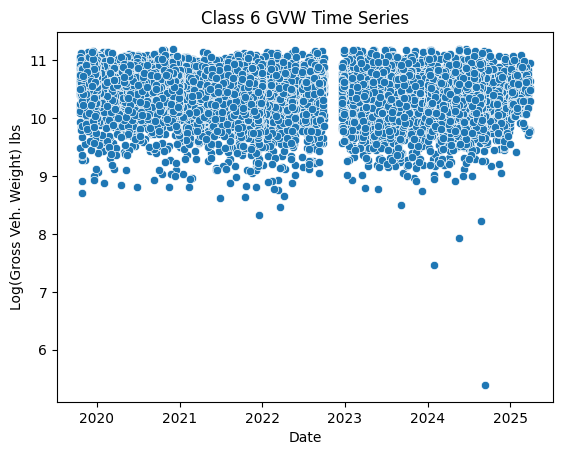

In [218]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#sample time series post outlier removal
class_df["log_gvw"] = np.log(class_df["gvw"])
sns.scatterplot(data=class_df, x="date", y="log_gvw")
plt.title(f"Class {class_num} GVW Time Series")
plt.xlabel("Date")
plt.ylabel("Log(Gross Veh. Weight) lbs")
plt.show()

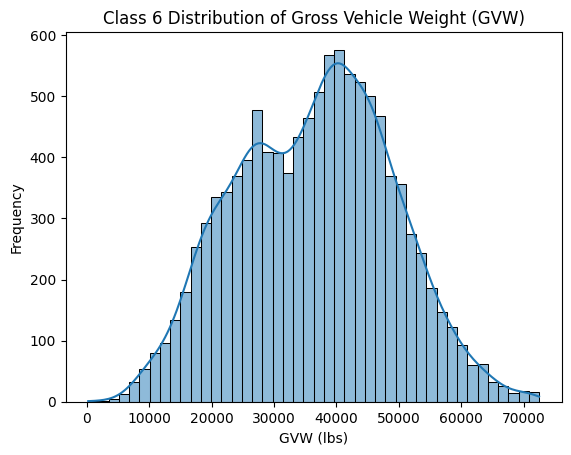

In [219]:
import seaborn as sns
import matplotlib.pyplot as plt

#GVW visualization
sns.histplot(data=class_df, x="gvw", kde=True)
plt.title(f"Class {class_num} Distribution of Gross Vehicle Weight (GVW)")
plt.xlabel("GVW (lbs)")
plt.ylabel("Frequency")
plt.show()

Class 7

In [220]:
import pandas as pd
#filtering by class
class_num = 7

count = df5.filter(f"class = {class_num}").count()
print(count)

class_df = df5.filter(f"class = {class_num}").toPandas()

97931


In [221]:
#converting date col to pandas date object
class_df["date"] = pd.to_datetime(class_df["date"], format="%y%m%d")

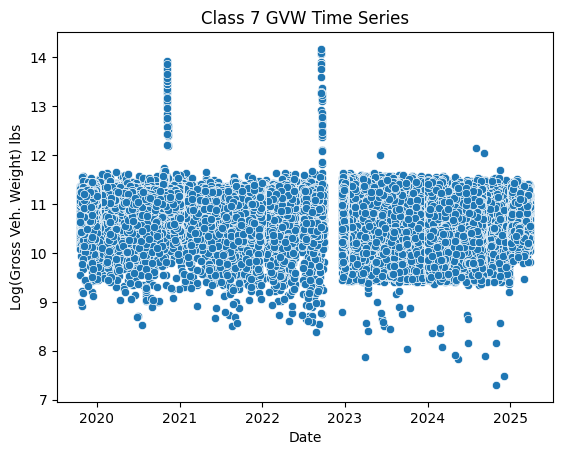

In [222]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

class_df["log_gvw"] = np.log(class_df["gvw"])
sns.scatterplot(data=class_df, x = "date", y="log_gvw")
plt.title(f"Class {class_num} GVW Time Series")
plt.xlabel("Date")
plt.ylabel("Log(Gross Veh. Weight) lbs")
plt.show()

In [223]:
class_df["gvw"].describe()

count    9.793100e+04
mean     5.849346e+04
std      2.864730e+04
min      1.480000e+03
25%      4.258500e+04
50%      6.268000e+04
75%      7.168000e+04
max      1.432730e+06
Name: gvw, dtype: float64

In [224]:
# Removing outliers
class_df["gvw"] = class_df["gvw"].astype("float")
class_df2 = remove_outliers_iqr(class_df)
class_df2["gvw"].describe()

Outlier Count: 126
Original Count: 97931
Remaining count: 97805
Outlier percentage: 0.13%
Upper bound: 115322.50, Lower bound: -1057.50


count     97805.000000
mean      57830.866520
std       18763.252111
min        1480.000000
25%       42520.000000
50%       62660.000000
75%       71650.000000
max      115040.000000
Name: gvw, dtype: float64

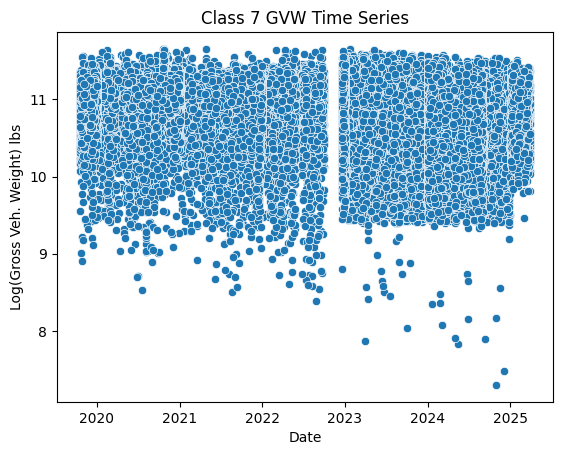

In [225]:
sns.scatterplot(data=class_df2, x = "date", y="log_gvw")
plt.title(f"Class {class_num} GVW Time Series")
plt.xlabel("Date")
plt.ylabel("Log(Gross Veh. Weight) lbs")
plt.show()

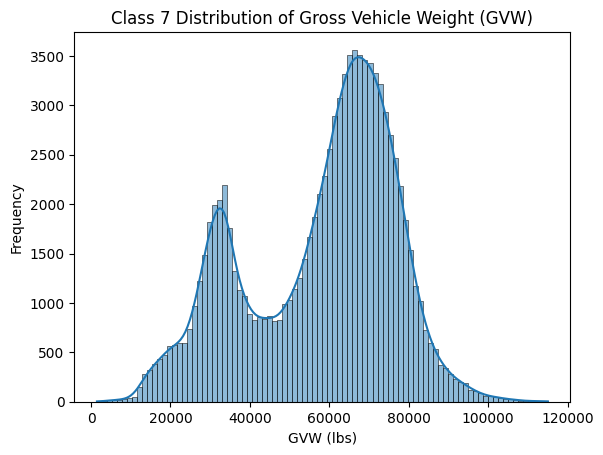

In [226]:
import seaborn as sns
import matplotlib.pyplot as plt

#GVW visualization
sns.histplot(data=class_df2, x="gvw", kde=True)
plt.title(f"Class {class_num} Distribution of Gross Vehicle Weight (GVW)")
plt.xlabel("GVW (lbs)")
plt.ylabel("Frequency")
plt.show()

Class 8

In [227]:
import pandas as pd
#filtering by class
class_num = 8

count = df5.filter(f"class = {class_num}").count()
print(count)

class_df = df5.filter(f"class = {class_num}").toPandas()

552164


In [228]:
#converting date col to pandas date object
class_df["date"] = pd.to_datetime(class_df["date"], format="%y%m%d")

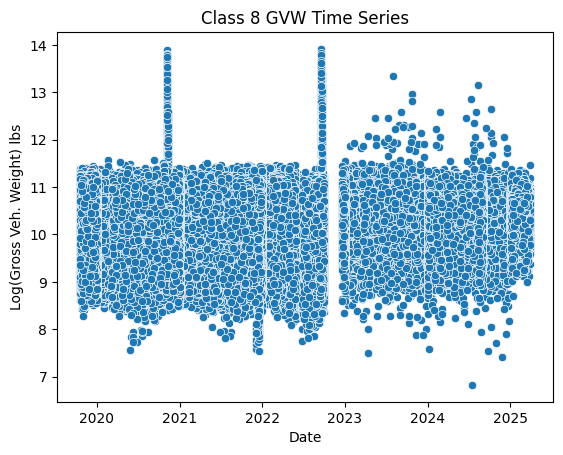

In [229]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

class_df["log_gvw"] = np.log(class_df["gvw"])
sns.scatterplot(data=class_df, x = "date", y="log_gvw")
plt.title(f"Class {class_num} GVW Time Series")
plt.xlabel("Date")
plt.ylabel("Log(Gross Veh. Weight) lbs")
plt.show()

In [230]:
class_df["gvw"].describe()

count    5.521640e+05
mean     4.196820e+04
std      2.695468e+04
min      9.200000e+02
25%      3.260000e+04
50%      4.241000e+04
75%      5.046000e+04
max      1.104660e+06
Name: gvw, dtype: float64

In [231]:
class_df2 = remove_outliers_iqr(class_df)
class_df2["gvw"].describe()

Outlier Count: 3629
Original Count: 552164
Remaining count: 548535
Outlier percentage: 0.66%
Upper bound: 77250.00, Lower bound: 5810.00


count    548535.000000
mean      40915.558594
std       13172.618164
min        5810.000000
25%       32610.000000
50%       42370.000000
75%       50360.000000
max       77250.000000
Name: gvw, dtype: float64

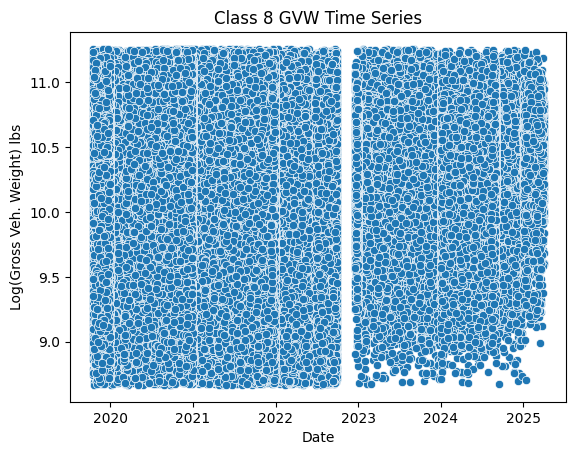

In [232]:
sns.scatterplot(data=class_df2, x = "date", y="log_gvw")
plt.title(f"Class {class_num} GVW Time Series")
plt.xlabel("Date")
plt.ylabel("Log(Gross Veh. Weight) lbs")
plt.show()

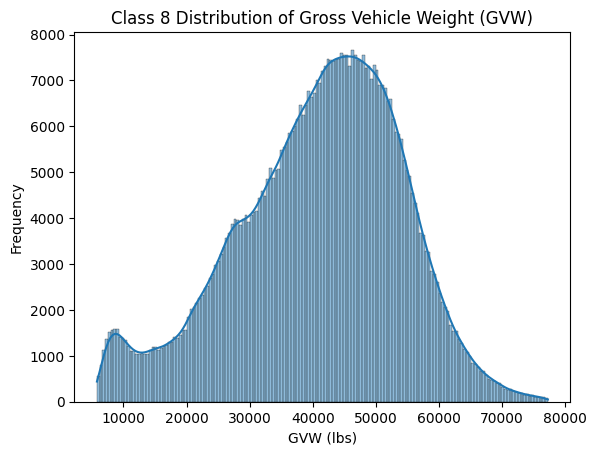

In [233]:
import seaborn as sns
import matplotlib.pyplot as plt

#GVW visualization
sns.histplot(data=class_df2, x="gvw", kde=True)
plt.title(f"Class {class_num} Distribution of Gross Vehicle Weight (GVW)")
plt.xlabel("GVW (lbs)")
plt.ylabel("Frequency")
plt.show()

Class 9

In [234]:
import pandas as pd
#filtering by class
class_num = 9
sample_ratio = 0.01

count = df5.filter(f"class = {class_num}").count()
print(f"Number of records {count}")
print(f"Number of records sampled {count*sample_ratio}")

Number of records 2301088
Number of records sampled 23010.88


In [235]:
class_df_spark = df5.filter(f"class = {class_num}")

In [236]:
#Getting statistics of complete dataset
class_df_spark.select("gvw").summary().show()

+-------+------------------+
|summary|               gvw|
+-------+------------------+
|  count|           2301088|
|   mean| 60696.34697151956|
| stddev|36481.783216737145|
|    min|            1520.0|
|    25%|           44570.0|
|    50%|           59560.0|
|    75%|           75590.0|
|    max|         1773850.0|
+-------+------------------+



In [237]:
df_no_outliers = remove_outliers_iqr2(class_df_spark, "gvw")
df_no_outliers.show(5)


Upper bound: 121400.0, Lower bound: -1800.0
+---------+----+-----+---+----+------+------+----+-----+-----+---------+-------+---------+-----+----+-----+----+-----+----+-----+----+-----+----+----+----+----+----+----+----+----+----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+---------+---------+------+
|direction|year|month|day|hour|minute|second|lane|class|speed|num_axles|    gvw|wheelbase|  wt1|spc1|  wt2|spc2|  wt3|spc3|  wt4|spc4|  wt5|spc5| wt6|spc6| wt7|spc7| wt8|spc8| wt9|spc9|wt10|spc10|wt11|spc11|wt12|spc12|wt13|spc13|wt14|spc14|wt15|spc15|wt16|spc16|wt17|dirtravel|yearmonth|  date|
+---------+----+-----+---+----+------+------+----+-----+-----+---------+-------+---------+-----+----+-----+----+-----+----+-----+----+-----+----+----+----+----+----+----+----+----+----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+-----+----+---------+---------+------+
|       QB|  23|    9| 22|   8|    13|    59|   1|    9|   42|        5

In [238]:
#outliers eliminated
a = class_df_spark.count()
b = df_no_outliers.count()
outlier_count = a - b

print(f"Outlier Count: {outlier_count}, Original Count: {a}, Remaining count {b}, Outlier percentage: {outlier_count/a*100:.2f}%")

Outlier Count: 5868, Original Count: 2301088, Remaining count 2295220, Outlier percentage: 0.26%


In [239]:
#Getting statistics of complete dataset with no outliers
df_no_outliers.select("gvw").summary().show()

+-------+-----------------+
|summary|              gvw|
+-------+-----------------+
|  count|          2295220|
|   mean|59401.54980786156|
| stddev|19210.51339047603|
|    min|           1520.0|
|    25%|          44530.0|
|    50%|          59470.0|
|    75%|          75490.0|
|    max|         121400.0|
+-------+-----------------+



In [97]:
#Bootstrap to check sampling error
#Outliers removed
sample_vars = []
sample_means = []

for i in range(50):
    class_df = df_no_outliers.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
    ).toPandas()
    
    sample_means.append(class_df["gvw"].mean())
    sample_vars.append(class_df["gvw"].var())
    print(f"{i+1}/50")

1/50
2/50
3/50
4/50
5/50
6/50
7/50
8/50
9/50
10/50
11/50
12/50
13/50
14/50
15/50
16/50
17/50
18/50
19/50
20/50
21/50
22/50
23/50
24/50
25/50
26/50
27/50
28/50
29/50
30/50
31/50
32/50
33/50
34/50
35/50
36/50
37/50
38/50
39/50
40/50
41/50
42/50
43/50
44/50
45/50
46/50
47/50
48/50
49/50
50/50


In [98]:
import statistics as stats
#Mean and error of sample mean

print(stats.mean(sample_means))
print(stats.variance(sample_means))

print(stats.stdev(sample_means)/stats.mean(sample_means)) #Coefficient of variation , CV

59407.66
12089.685
0.0018508236


In [99]:
import statistics as stats
#Mean and error of sample variance

print(stats.mean(sample_vars))
print(stats.variance(sample_vars))

print(stats.stdev(sample_vars)/stats.mean(sample_vars)) #Coefficient of variation , CV

368930913.92
7419863596613.381
0.007383340766129354


In [240]:
#Sampled dataset without replacement for visualization
class_df = df_no_outliers.sample(
    withReplacement=False,  
    fraction=sample_ratio,           
    seed=42                 
).toPandas()

In [241]:
#converting date col to pandas date object
class_df["date"] = pd.to_datetime(class_df["date"], format="%y%m%d")

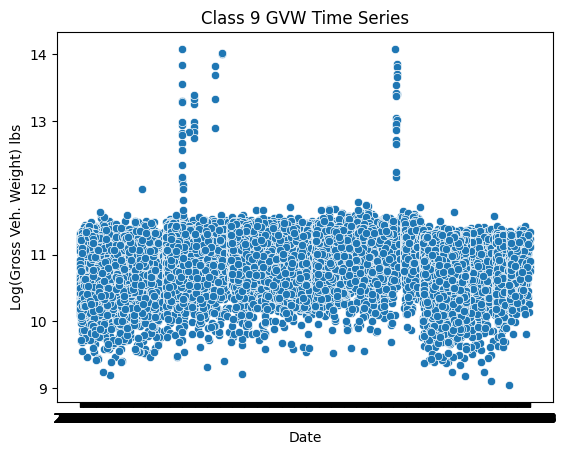

In [242]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#Pre-removing outlier sample time series
og_sample = class_df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,           
    seed=42                 
).toPandas()

og_sample["log_gvw"] = np.log(og_sample["gvw"])
sns.scatterplot(data=og_sample, x="date", y="log_gvw")
plt.title(f"Class {class_num} GVW Time Series")
plt.xlabel("Date")
plt.ylabel("Log(Gross Veh. Weight) lbs")
plt.show()

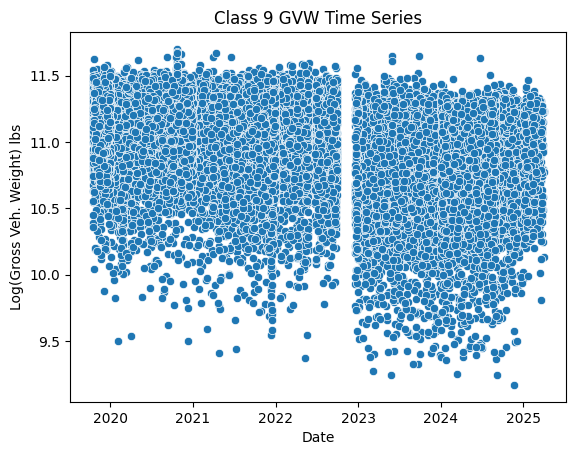

In [243]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#sample time series post outlier removal
class_df["log_gvw"] = np.log(class_df["gvw"])
sns.scatterplot(data=class_df, x="date", y="log_gvw")
plt.title(f"Class {class_num} GVW Time Series")
plt.xlabel("Date")
plt.ylabel("Log(Gross Veh. Weight) lbs")
plt.show()

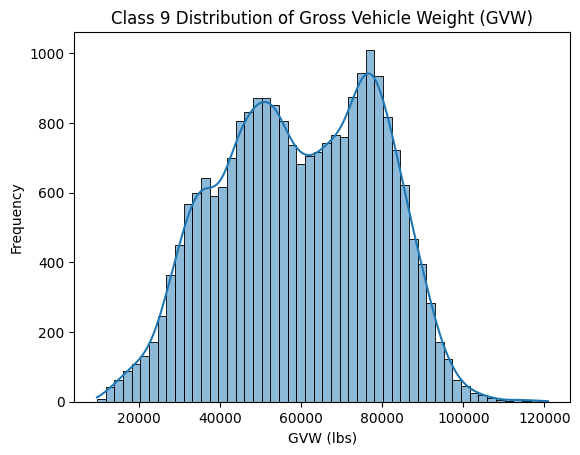

In [244]:
import seaborn as sns
import matplotlib.pyplot as plt

#GVW visualization
sns.histplot(data=class_df, x="gvw", kde=True)
plt.title(f"Class {class_num} Distribution of Gross Vehicle Weight (GVW)")
plt.xlabel("GVW (lbs)")
plt.ylabel("Frequency")
plt.show()

Class 10

In [245]:
import pandas as pd
#filtering by class
class_num = 10

count = df5.filter(f"class = {class_num}").count()
print(count)

class_df = df5.filter(f"class = {class_num}").toPandas()

93306


In [246]:
#converting date col to pandas date object
class_df["date"] = pd.to_datetime(class_df["date"], format="%y%m%d")

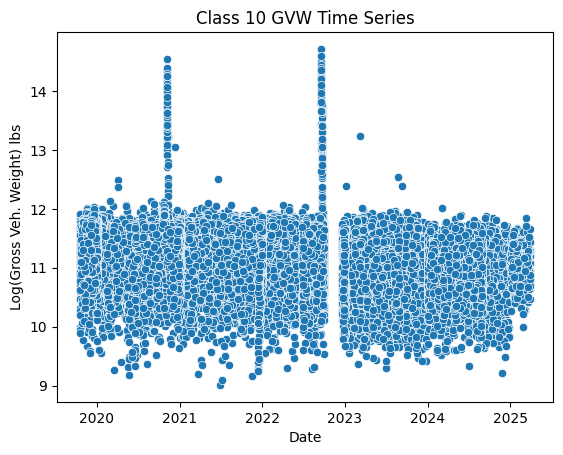

In [247]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

class_df["log_gvw"] = np.log(class_df["gvw"])
sns.scatterplot(data=class_df, x = "date", y="log_gvw")
plt.title(f"Class {class_num} GVW Time Series")
plt.xlabel("Date")
plt.ylabel("Log(Gross Veh. Weight) lbs")
plt.show()

In [248]:
class_df["gvw"].describe()

count    9.330600e+04
mean     9.203266e+04
std      5.700994e+04
min      8.210000e+03
25%      6.827000e+04
50%      9.673000e+04
75%      1.114100e+05
max      2.451190e+06
Name: gvw, dtype: float64

In [249]:
#Removing outliers
class_df2 = remove_outliers_iqr(class_df)
class_df2["gvw"].describe()

Outlier Count: 240
Original Count: 93306
Remaining count: 93066
Outlier percentage: 0.26%
Upper bound: 176120.00, Lower bound: 3560.00


count     93066.000000
mean      89848.273438
std       27683.908203
min        8210.000000
25%       68190.000000
50%       96650.000000
75%      111300.000000
max      175620.000000
Name: gvw, dtype: float64

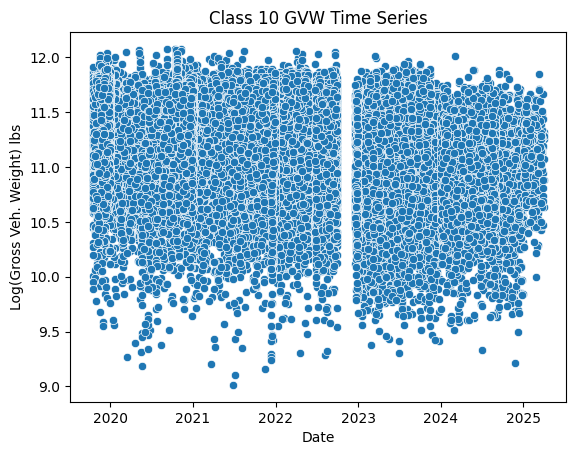

In [250]:
sns.scatterplot(data=class_df2, x = "date", y="log_gvw")
plt.title(f"Class {class_num} GVW Time Series")
plt.xlabel("Date")
plt.ylabel("Log(Gross Veh. Weight) lbs")
plt.show()

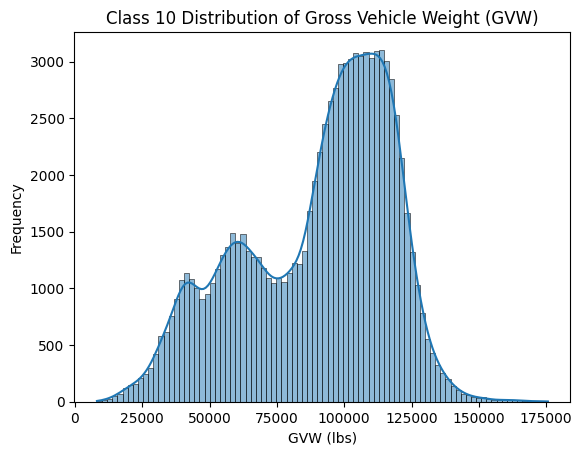

In [251]:
import seaborn as sns
import matplotlib.pyplot as plt

#GVW visualization
sns.histplot(data=class_df2, x="gvw", kde=True)
plt.title(f"Class {class_num} Distribution of Gross Vehicle Weight (GVW)")
plt.xlabel("GVW (lbs)")
plt.ylabel("Frequency")
plt.show()

Class 11

In [252]:
import pandas as pd
#filtering by class
class_num = 11

count = df5.filter(f"class = {class_num}").count()
print(count)

class_df = df5.filter(f"class = {class_num}").toPandas()

70407


In [253]:
#converting date col to pandas date object
class_df["date"] = pd.to_datetime(class_df["date"], format="%y%m%d")

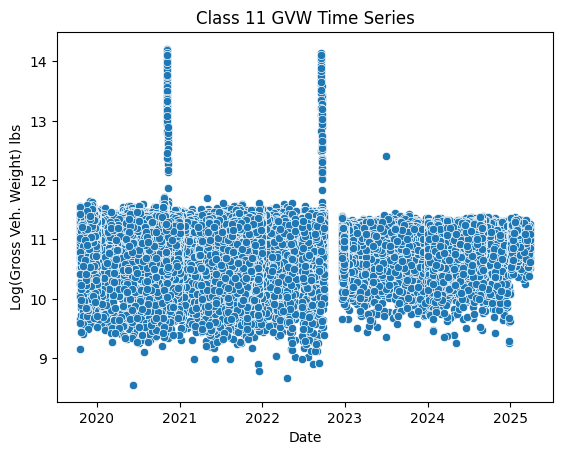

In [254]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

class_df["log_gvw"] = np.log(class_df["gvw"])
sns.scatterplot(data=class_df, x = "date", y="log_gvw")
plt.title(f"Class {class_num} GVW Time Series")
plt.xlabel("Date")
plt.ylabel("Log(Gross Veh. Weight) lbs")
plt.show()

In [255]:
class_df["gvw"].describe()

count    7.040700e+04
mean     6.593262e+04
std      4.003381e+04
min      5.160000e+03
25%      5.498000e+04
50%      6.721000e+04
75%      7.522000e+04
max      1.486010e+06
Name: gvw, dtype: float64

In [256]:
#Removing outliers
class_df2 = remove_outliers_iqr(class_df)
class_df2["gvw"].describe()

Outlier Count: 1714
Original Count: 70407
Remaining count: 68693
Outlier percentage: 2.43%
Upper bound: 105580.00, Lower bound: 24620.00


count     68693.000000
mean      65244.980469
std       14325.239258
min       24620.000000
25%       55980.000000
50%       67490.000000
75%       75300.000000
max      105530.000000
Name: gvw, dtype: float64

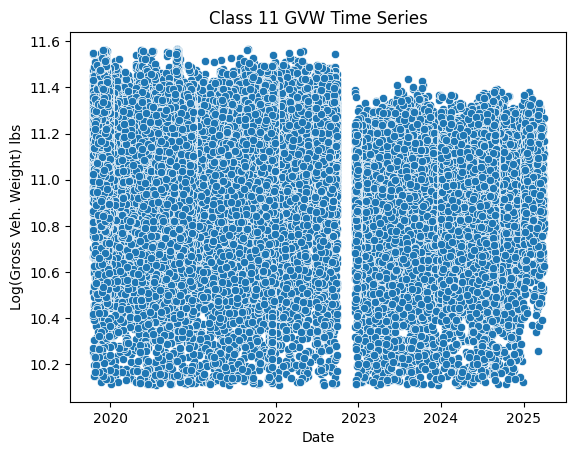

In [257]:
sns.scatterplot(data=class_df2, x = "date", y="log_gvw")
plt.title(f"Class {class_num} GVW Time Series")
plt.xlabel("Date")
plt.ylabel("Log(Gross Veh. Weight) lbs")
plt.show()

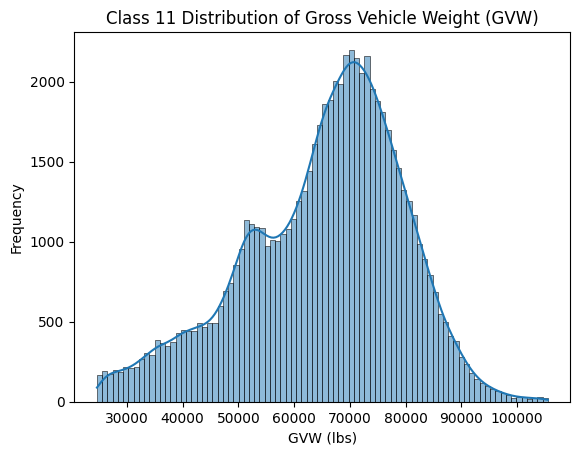

In [258]:
import seaborn as sns
import matplotlib.pyplot as plt

#GVW visualization
sns.histplot(data=class_df2, x="gvw", kde=True)
plt.title(f"Class {class_num} Distribution of Gross Vehicle Weight (GVW)")
plt.xlabel("GVW (lbs)")
plt.ylabel("Frequency")
plt.show()

Class 12


In [259]:
import pandas as pd
#filtering by class
class_num = 12

count = df5.filter(f"class = {class_num}").count()
print(count)

class_df = df5.filter(f"class = {class_num}").toPandas()

32837


In [260]:
#converting date col to pandas date object
class_df["date"] = pd.to_datetime(class_df["date"], format="%y%m%d")

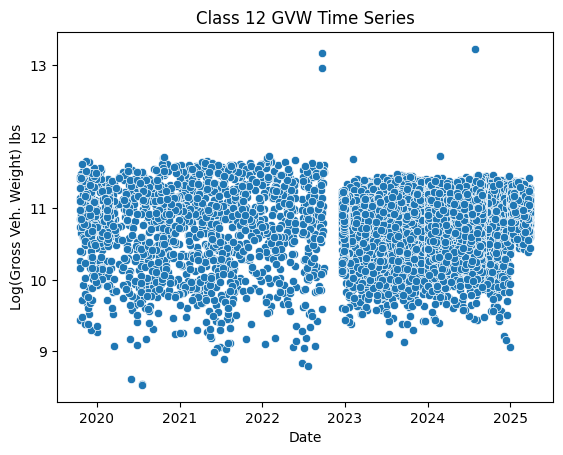

In [261]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

class_df["log_gvw"] = np.log(class_df["gvw"])
sns.scatterplot(data=class_df, x = "date", y="log_gvw")
plt.title(f"Class {class_num} GVW Time Series")
plt.xlabel("Date")
plt.ylabel("Log(Gross Veh. Weight) lbs")
plt.show()

In [262]:
class_df["gvw"].describe()

count     32837.000000
mean      59192.535156
std       14827.243164
min        5060.000000
25%       52420.000000
50%       61520.000000
75%       68400.000000
max      557080.000000
Name: gvw, dtype: float64

In [263]:
#Removing outliers
class_df2 = remove_outliers_iqr(class_df)
class_df2["gvw"].describe()

Outlier Count: 1478
Original Count: 32837
Remaining count: 31359
Outlier percentage: 4.50%
Upper bound: 92370.00, Lower bound: 28450.00


count    31359.000000
mean     60279.136719
std      11828.504883
min      28460.000000
25%      53745.000000
50%      62040.000000
75%      68480.000000
max      92360.000000
Name: gvw, dtype: float64

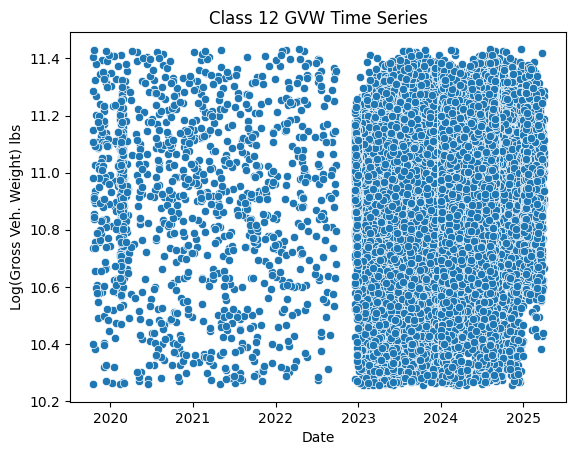

In [264]:
sns.scatterplot(data=class_df2, x = "date", y="log_gvw")
plt.title(f"Class {class_num} GVW Time Series")
plt.xlabel("Date")
plt.ylabel("Log(Gross Veh. Weight) lbs")
plt.show()

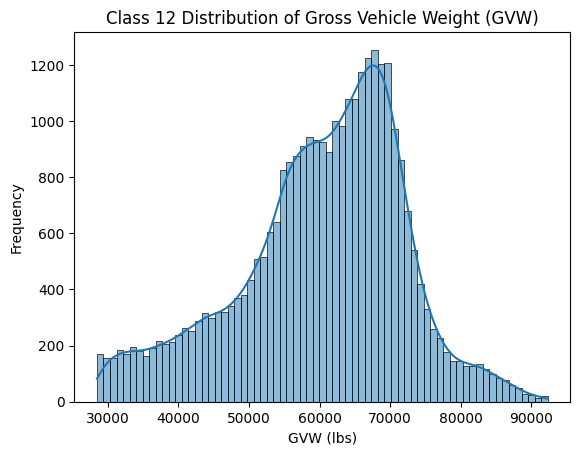

In [265]:
import seaborn as sns
import matplotlib.pyplot as plt

#GVW visualization
sns.histplot(data=class_df2, x="gvw", kde=True)
plt.title(f"Class {class_num} Distribution of Gross Vehicle Weight (GVW)")
plt.xlabel("GVW (lbs)")
plt.ylabel("Frequency")
plt.show()

Class 13

In [266]:
import pandas as pd
#filtering by class
class_num = 13

count = df5.filter(f"class = {class_num}").count()
print(count)

class_df = df5.filter(f"class = {class_num}").toPandas()

6765


In [267]:
#converting date col to pandas date object
class_df["date"] = pd.to_datetime(class_df["date"], format="%y%m%d")

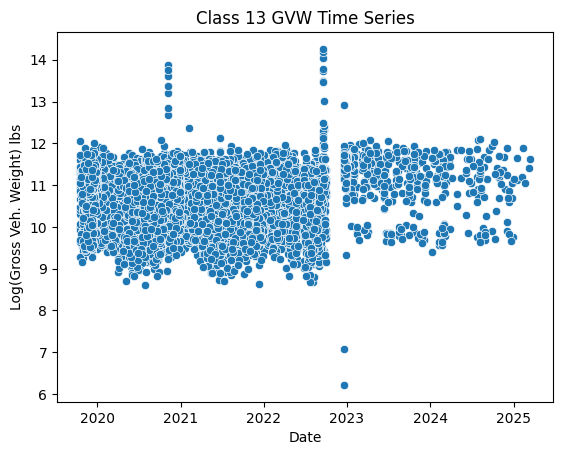

In [268]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

class_df["log_gvw"] = np.log(class_df["gvw"])
sns.scatterplot(data=class_df, x = "date", y="log_gvw")
plt.title(f"Class {class_num} GVW Time Series")
plt.xlabel("Date")
plt.ylabel("Log(Gross Veh. Weight) lbs")
plt.show()

In [269]:
class_df["gvw"].describe()

count    6.757000e+03
mean     6.091874e+04
std      5.301371e+04
min      5.000000e+02
25%      2.761000e+04
50%      5.835000e+04
75%      8.323000e+04
max      1.558080e+06
Name: gvw, dtype: float64

In [270]:
#Removing outliers
class_df2 = remove_outliers_iqr(class_df)
class_df2["gvw"].describe()

Outlier Count: 32
Original Count: 6765
Remaining count: 6733
Outlier percentage: 0.47%
Upper bound: 166660.00, Lower bound: -55820.00


count      6725.000000
mean      58776.019531
std       32915.394531
min         500.000000
25%       27500.000000
50%       58180.000000
75%       82850.000000
max      164110.000000
Name: gvw, dtype: float64

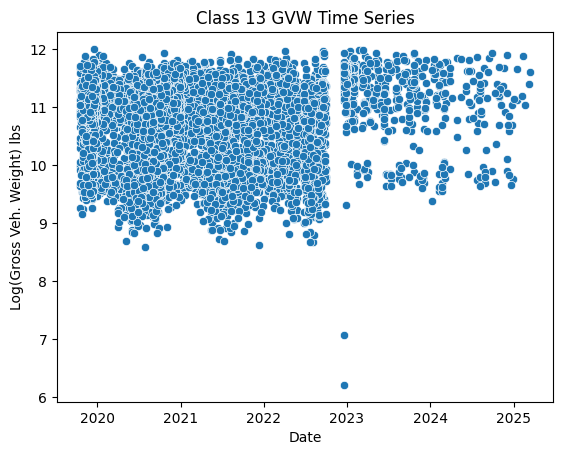

In [271]:
sns.scatterplot(data=class_df2, x = "date", y="log_gvw")
plt.title(f"Class {class_num} GVW Time Series")
plt.xlabel("Date")
plt.ylabel("Log(Gross Veh. Weight) lbs")
plt.show()

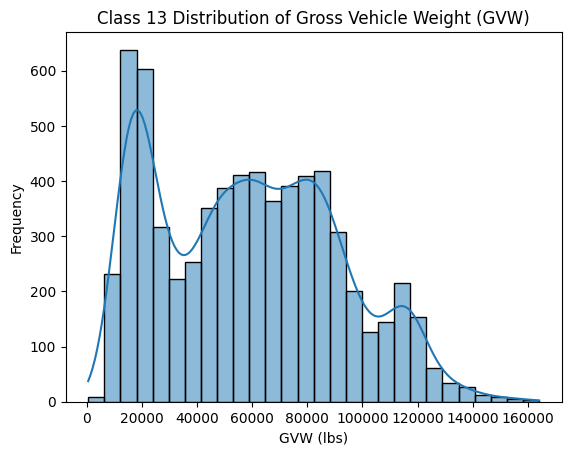

In [272]:
import seaborn as sns
import matplotlib.pyplot as plt

#GVW visualization
sns.histplot(data=class_df2, x="gvw", kde=True)
plt.title(f"Class {class_num} Distribution of Gross Vehicle Weight (GVW)")
plt.xlabel("GVW (lbs)")
plt.ylabel("Frequency")
plt.show()

In [274]:
spark.stop()